In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("Retail Sales Dataset.csv")

In [4]:
df.head()

,Order ID,Date,Customer ID,Gender,Age,Product Category,Payment Method,City,Store Type,Quantity,Price per Unit,Total Amount,Total Price,Delivery Status,High Value Order,Sales Rep E-mail
0,559,01/01/2023,CUST559,Female,40,Clothing,Credit Card,Miami,Department Store,4,300,1200,1200,Pending,Yes,miamirep@gmail.com
1,180,01/01/2023,CUST180,Male,41,Clothing,Debit Card,San Francisco,Pharmacy,3,300,900,900,Pending,Yes,sanfranciscorep@gmail.com
2,522,01/01/2023,CUST522,Male,46,Beauty,Debit Card,San Francisco,Specialty Store,3,500,1500,1500,Completed,Yes,sanfranciscorep@gmail.com
3,979,02/01/2023,CUST979,Female,19,Beauty,Mobile Payment,Boston,Convenience Store,1,25,25,25,Completed,No,bostonrep@gmail.com
4,163,02/01/2023,CUST163,Female,64,Clothing,Mobile Payment,Chicago,Pharmacy,3,50,150,150,Pending,No,chicagorep@gmail.com


In [5]:
df.shape

(1000, 16)

In [6]:
df.dtypes

Order ID             int64
Date                   str
Customer ID            str
Gender                 str
Age                  int64
Product Category       str
Payment Method         str
City                   str
Store Type             str
Quantity             int64
Price per Unit       int64
Total Amount         int64
Total Price          int64
Delivery Status        str
High Value Order       str
Sales Rep E-mail       str
dtype: object

In [8]:
df.isnull().sum()

Order ID             0
Date                 0
Customer ID          0
Gender               0
Age                  0
Product Category     0
Payment Method       0
City                 0
Store Type           0
Quantity             0
Price per Unit       0
Total Amount         0
Total Price          0
Delivery Status      0
High Value Order     0
Sales Rep E-mail     0
dtype: int64

In [9]:
df.mean(numeric_only=True)

Order ID          500.500
Age                41.392
Quantity            2.632
Price per Unit    179.890
Total Amount      476.160
Total Price       476.160
dtype: float64

In [11]:
df.median(numeric_only=True)

Order ID          500.5
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      150.0
Total Price       150.0
dtype: float64

In [12]:
df.mode(numeric_only=True)

,Order ID,Age,Quantity,Price per Unit,Total Amount,Total Price
0,1,43.0,1.0,50.0,50.0,50.0
1,2,64.0,NaN,NaN,NaN,NaN
2,3,NaN,NaN,NaN,NaN,NaN
3,4,NaN,NaN,NaN,NaN,NaN
4,5,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
995,996,NaN,NaN,NaN,NaN,NaN
996,997,NaN,NaN,NaN,NaN,NaN
997,998,NaN,NaN,NaN,NaN,NaN
998,999,NaN,NaN,NaN,NaN,NaN


In [16]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

In [13]:
df.std(numeric_only=True)

Order ID          288.819436
Age                13.681430
Quantity            1.465853
Price per Unit    189.681356
Total Amount      620.188349
Total Price       620.188349
dtype: float64

In [19]:
monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Total Amount'].sum()

In [20]:
monthly_sales

Date
2023-01    38630
2023-02    45410
2023-03    30330
2023-04    38480
2023-05    56450
2023-06    36715
2023-07    35865
2023-08    37260
2023-09    23620
2023-10    50080
2023-11    37100
2023-12    44690
2024-01     1530
Freq: M, Name: Total Amount, dtype: int64

<Axes: xlabel='Date'>

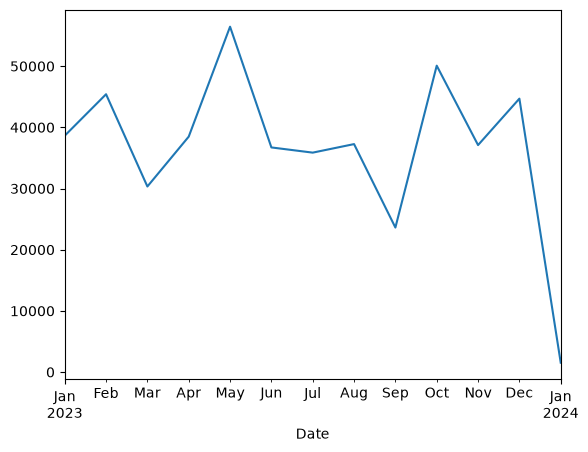

In [22]:
monthly_sales.plot(kind='line')

Observation: Sales fluctuate month to monyh. The highest sales are observed in May 2023, where sales exceed ₹50,000.

In [7]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

In [8]:
df['Date'].dtype

dtype('<M8[us]')

In [9]:
quarterly_sales = df.groupby(df['Date'].dt.to_period('Q'))['Total Amount'].sum()
quarterly_sales

Date
2023Q1    114370
2023Q2    131645
2023Q3     96745
2023Q4    131870
2024Q1      1530
Freq: Q-DEC, Name: Total Amount, dtype: int64

<Axes: xlabel='Date'>

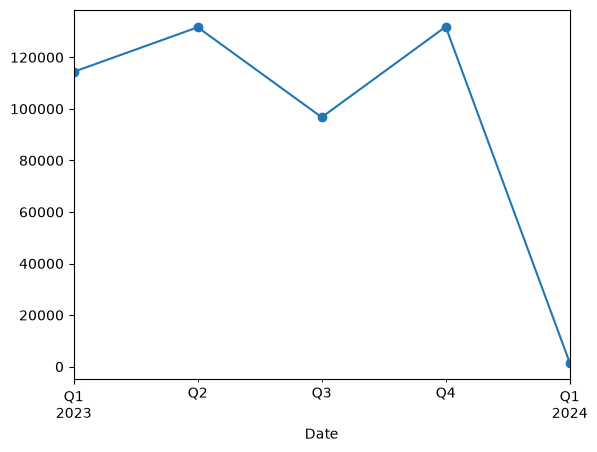

In [11]:
quarterly_sales.plot(kind='line',marker='o')

Observation: Quarterly sales show fluctuations accross the year. Q2 and Q4 recorded the highest sales.

In [12]:
df['Age'].min(), df['Age'].max()

(np.int64(18), np.int64(64))

In [13]:
age_groups = pd.cut(
    df['Age'],
    bins=[17,25,35,45,55,65],
    labels=['18-25','26-35','36-45','46-55','56-64']
)
age_groups.value_counts().sort_index()

Age
18-25    169
26-35    205
36-45    202
46-55    229
56-64    195
Name: count, dtype: int64

<Axes: xlabel='Age'>

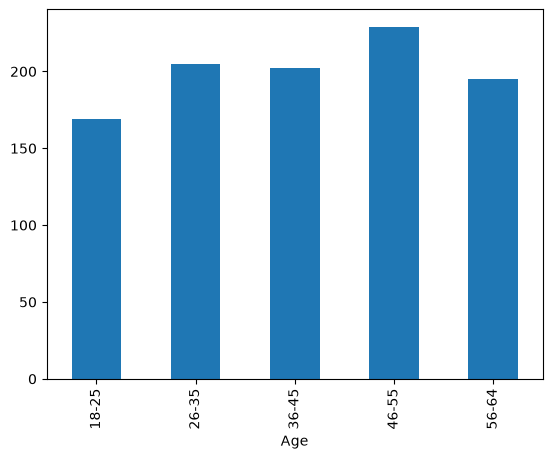

In [14]:
age_groups.value_counts().sort_index().plot(kind='bar')

Observation: The 46-55 age group has the highest number of customers.

In [15]:
df['Gender'].value_counts()

Gender
Female    510
Male      490
Name: count, dtype: int64

<Axes: xlabel='Gender'>

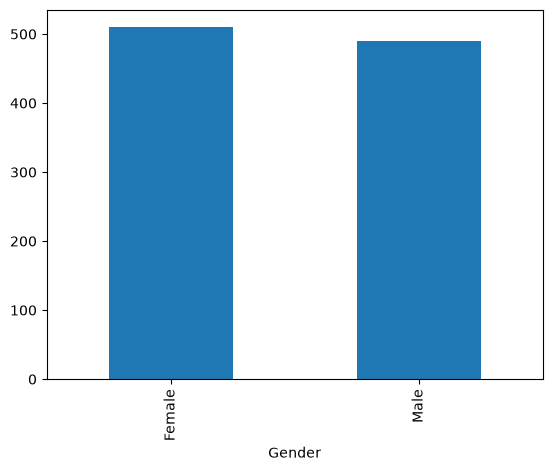

In [16]:
df['Gender'].value_counts().plot(kind='bar')

Observation: The number of female customers is slightly higher than the number of male customers.

In [18]:
df.columns

Index(['Order ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category',
       'Payment Method', 'City', 'Store Type', 'Quantity', 'Price per Unit',
       'Total Amount', 'Total Price', 'Delivery Status', 'High Value Order',
       'Sales Rep E-mail '],
      dtype='str')

In [19]:
df.groupby('Product Category')['Quantity'].sum().sort_values(ascending=False)

Product Category
Clothing       939
Electronics    882
Beauty         811
Name: Quantity, dtype: int64

In [20]:
import matplotlib.pyplot as plt

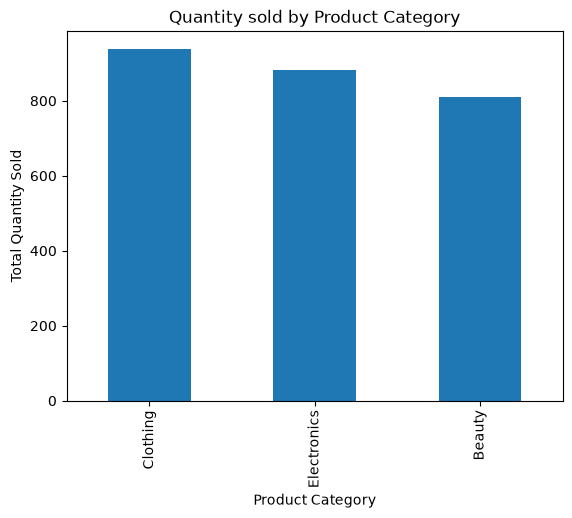

In [21]:
category_quantity=df.groupby('Product Category')['Quantity'].sum().sort_values(ascending=False)
category_quantity.plot(kind='bar')
plt.title('Quantity sold by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Quantity Sold')
plt.show()

Obervation: Clothing has the highest quantity sold(939 units), followed by Electronics(882 units) and Beauty(811 units).

<function matplotlib.pyplot.show(close=None, block=None)>

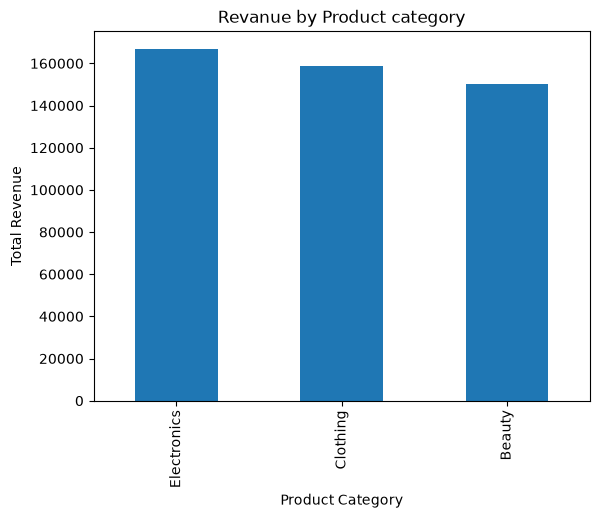

In [22]:
category_revenue = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)
category_revenue.plot(kind='bar')
plt.title('Revanue by Product category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.show

Observation: Electronics generated the highest revenue, with sales exceeding ₹160,000. Clothing and Beauty generated comparatively lower revenue.

<function matplotlib.pyplot.show(close=None, block=None)>

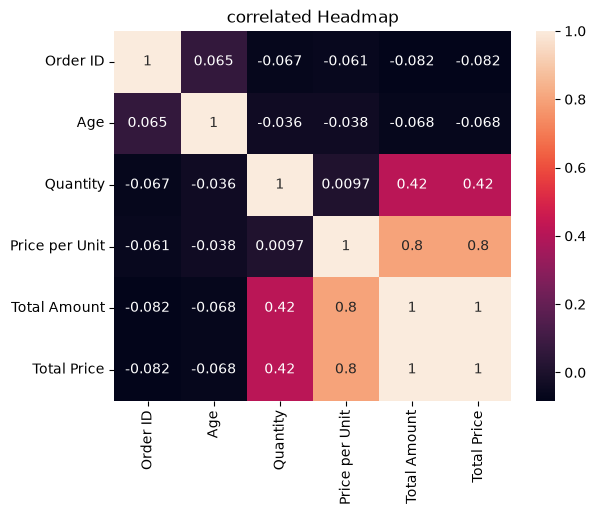

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.select_dtypes(include='number').corr()

sns.heatmap(corr,annot=True)

plt.title('correlated Headmap')
plt.show

In [24]:
corr

,Order ID,Age,Quantity,Price per Unit,Total Amount,Total Price
Order ID,1.000000,0.065191,-0.067449,-0.060837,-0.082232,-0.082232
Age,0.065191,1.000000,-0.036074,-0.038423,-0.068242,-0.068242
Quantity,-0.067449,-0.036074,1.000000,0.009683,0.416493,0.416493
Price per Unit,-0.060837,-0.038423,0.009683,1.000000,0.800329,0.800329
Total Amount,-0.082232,-0.068242,0.416493,0.800329,1.000000,1.000000
Total Price,-0.082232,-0.068242,0.416493,0.800329,1.000000,1.000000


Observation: The headmap shows a strong positive correlation between Price per Unit and Total Amount (0.08). Quantity also has a moderate positive correlation with Total Amount(0.42). Most other variables show weak correlations.

<function matplotlib.pyplot.show(close=None, block=None)>

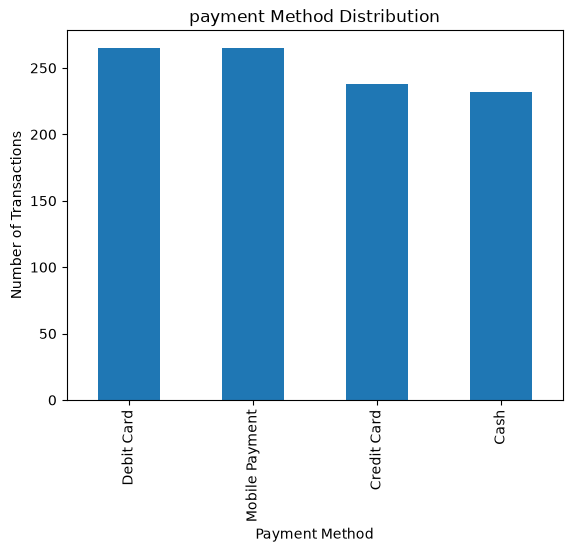

In [26]:
payment_counts = df['Payment Method'].value_counts()

payment_counts.plot(kind='bar')

plt.title('payment Method Distribution')
plt.xlabel('Payment Method')
plt.ylabel('Number of Transactions')
plt.show

In [27]:
payment_counts

Payment Method
Debit Card        265
Mobile Payment    265
Credit Card       238
Cash              232
Name: count, dtype: int64

Observation: Debit Card and Mobile Payment are the most commonly used payment methods, with 265 transactions each. Credit card and cash are used less frequently.

### Dataset Limitation
Note: The dataset contains Product Category information but does not contain individual product names. Therefore, product-level Top 10 analysis could not be performed using dataset.

## Conclusion
The analysis shows that sales vary across months and quarters, with May 2023 having the highest monthly sales. Q2 and Q4 also show strong sales performance. The 46-55 age group has the highest customer count, while female customers are slightly higher than male customers. Clothing has the highest quantity sold, whereas Electronics generates the highest revenue. The correlation analysis shows a strong positive relationship between Price per unit and Total Amount. Debit card and Mobile Payment are the most commonly used payment methods.

### Business Recommendations
1. Focus marketing compaigns on the 46-55 age group, as it has the highest customer count.
2. Increase promotions and inventory planning for Electronics because it generates the highest revenue.
3. Maintain convenient payment options, especially Debit Card and Mobile Payment, as they are the most commonly used methods.
4. Plan special offers and campaigns during periods with historically higher sales, especially Q2 and Q4.